# 7주차: 확률 기초와 최대우도추정(MLE: maximum likelihood estimation)
> 인공지능수학 | 영상 강의용 노트북

---
## 🔮 Aha Moment — 예측부터 시작

동전을 10번 던졌더니 앞면이 7번 나왔습니다.  
이 동전의 앞면 확률 $p$는 얼마라고 추측하겠습니까?

아래 코드를 실행해보세요 — 아직 이해하지 않아도 됩니다.

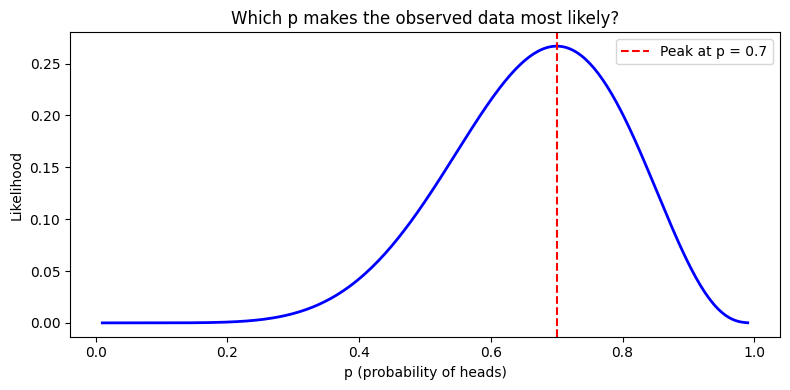

우도가 최대가 되는 p = 0.7
이것이 바로 최대우도추정(MLE)입니다.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# Data: 10 flips, 7 heads
n, k = 10, 7

# Compute likelihood for each candidate p
p_candidates = np.linspace(0.01, 0.99, 300)
likelihood = [comb(n, k) * (p**k) * ((1-p)**(n-k)) for p in p_candidates]

plt.figure(figsize=(8, 4))
plt.plot(p_candidates, likelihood, 'b-', linewidth=2)
plt.axvline(x=k/n, color='red', linestyle='--', label=f'Peak at p = {k/n}')
plt.xlabel('p (probability of heads)')
plt.ylabel('Likelihood')
plt.title('Which p makes the observed data most likely?')
plt.legend()
plt.tight_layout()
plt.show()

print(f"우도가 최대가 되는 p = {k/n}")
print("이것이 바로 최대우도추정(MLE)입니다.")

**왜 꼭짓점이 $p = 0.7$에서 나타날까요?**  
오늘 수업이 끝나면 이 질문에 수학으로 답할 수 있게 됩니다.

---

## 1. 확률이란 무엇인가?

### 1.1 사건과 표본공간

| 용어 |&nbsp;&nbsp; 기호&nbsp;&nbsp; | 의미 |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 예시 (동전 2번)&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|---|---|---|---|
| 표본공간 | $\Omega$ | 가능한 모든 결과의 집합 | $\{HH, HT, TH, TT\}$ |
| 사건 | $A$ | 표본공간의 부분집합 | $A = \{HH, HT\}$ (첫 번째 앞면) |
| 확률 | $P(A)$ | 사건이 일어날 비율 | $P(A) = 2/4 = 0.5$ |

확률의 세 가지 공리:
1. $P(A) \geq 0$ (비음수)
2. $P(\Omega) = 1$ (전체 확률은 1)
3. $P(A \cup B) = P(A) + P(B)$, 단 $A \cap B = \emptyset$ (배반 사건의 합산)

### 1.2 조건부 확률(Conditional Probability)

"$B$가 일어났다는 조건 아래서 $A$가 일어날 확률"을 **조건부 확률**이라 합니다.

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

**직관적으로:** $B$가 일어나면 표본공간이 $\Omega$ → $B$로 좁혀집니다.  
그 좁아진 공간 안에서 $A$가 차지하는 비율이 $P(A \mid B)$입니다.

#### 예시

카드 52장 중 한 장을 뽑을 때:
- $A$: 킹 카드 → $P(A) = 4/52$
- $B$: 스페이드 → $P(B) = 13/52$
- $A \cap B$: 스페이드 킹 → $P(A \cap B) = 1/52$

$$P(A \mid B) = \frac{1/52}{13/52} = \frac{1}{13}$$

스페이드 카드 중에 킹이 1장 있으므로 $1/13$ — 직관과 일치합니다.

In [5]:
# Verify conditional probability by simulation
np.random.seed(42)
N = 100_000

# Cards: 0~12 = spades, 13~25 = hearts, 26~38 = diamonds, 39~51 = clubs
draws = np.random.randint(0, 52, size=N)

is_spade = draws < 13          # B: spade
is_king  = draws % 13 == 12    # A: king (card index 12, 25, 38, 51)

# P(A|B) = P(A∩B) / P(B)
p_B     = is_spade.mean()
p_A_and_B = (is_spade & is_king).mean()
p_A_given_B = p_A_and_B / p_B

print(f"P(B) = P(spade)       = {p_B:.4f}  (이론: {13/52:.4f})")
print(f"P(A∩B) = P(spade∩king)= {p_A_and_B:.4f}  (이론: {1/52:.4f})")
print(f"P(A|B) = P(king|spade)= {p_A_given_B:.4f}  (이론: {1/13:.4f})")

P(B) = P(spade)       = 0.2480  (이론: 0.2500)
P(A∩B) = P(spade∩king)= 0.0196  (이론: 0.0192)
P(A|B) = P(king|spade)= 0.0789  (이론: 0.0769)


### 1.3 독립 사건(Independence)

$$A \perp B \iff P(A \cap B) = P(A) \cdot P(B)$$

동치 조건: $P(A \mid B) = P(A)$ — $B$의 발생이 $A$의 확률에 영향을 주지 않는다.

**주의:** 서로소(mutually exclusive)와 독립(independent)은 **다른 개념**입니다.
- 서로소: $A \cap B = \emptyset$ → 하나가 일어나면 다른 하나는 **절대** 일어나지 않음
- 독립: 하나가 일어나도 다른 하나의 확률에 **영향 없음**

---
## 2. 확률분포(Probability Distribution)

> 확률분포(probability distribution): 확률변수가 특정한 값을 가질 확률을 나타내는 함수

> 이산확률변수(discrete random variable): probability mass function

> 연속확률변수(continuous random variable): probability density function

### 2.1 이산 확률분포 — 이항분포(Binomial Distribution)

**설정:** 성공 확률 $p$인 시행을 $n$번 독립적으로 반복할 때, 성공 횟수 $k$

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

- $\binom{n}{k}$: $n$번 중 $k$번을 선택하는 경우의 수
- $p^k$: $k$번 성공할 확률
- $(1-p)^{n-k}$: $n-k$번 실패할 확률
- 세 항의 곱: 독립 시행이므로 확률을 곱한다

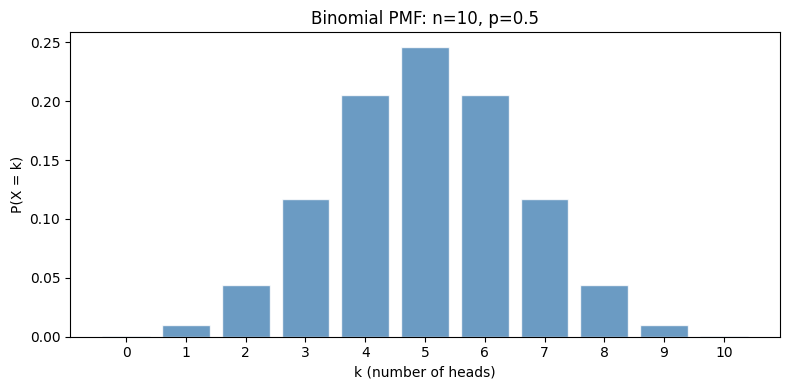

P(X=7) when n=10, p=0.5: 0.1172
P(X=7) when n=10, p=0.7: 0.2668


In [11]:
from math import comb

def binomial_pmf(n, k, p):
    """P(X=k) for Binomial(n, p)"""
    # combination * p^k * (1-p)^(n-k)
    return comb(n, k) * (p**k) * ((1-p)**(n-k))

# Example: n=10, p=0.5 (fair coin)
n, p = 10, 0.5
k_values = np.arange(0, n+1)
probs = [binomial_pmf(n, k, p) for k in k_values]

plt.figure(figsize=(8, 4))
plt.bar(k_values, probs, color='steelblue', alpha=0.8, edgecolor='white')
plt.xlabel('k (number of heads)')
plt.ylabel('P(X = k)')
plt.title(f'Binomial PMF: n={n}, p={p}')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print(f"P(X=7) when n=10, p=0.5: {binomial_pmf(10, 7, 0.5):.4f}")
print(f"P(X=7) when n=10, p=0.7: {binomial_pmf(10, 7, 0.7):.4f}")

### 2.2 연속 확률분포 — 정규분포(Normal Distribution)

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- $\mu$: 평균(분포의 중심)
- $\sigma$: 표준편차(분포의 퍼짐 정도)
- $f(x)$: 확률밀도함수(PDF) — 점의 확률이 아니라 밀도
- 연속분포에서 특정 점의 확률은 $P(X=x)=0$, 구간의 확률만 의미 있음: $P(a \leq X \leq b) = \int_a^b f(x)\,dx$

**8주차 연결:** 로지스틱회귀에서 데이터의 noise를 정규분포로 모델링하면 MLE = MSE 최소화로 이어집니다.

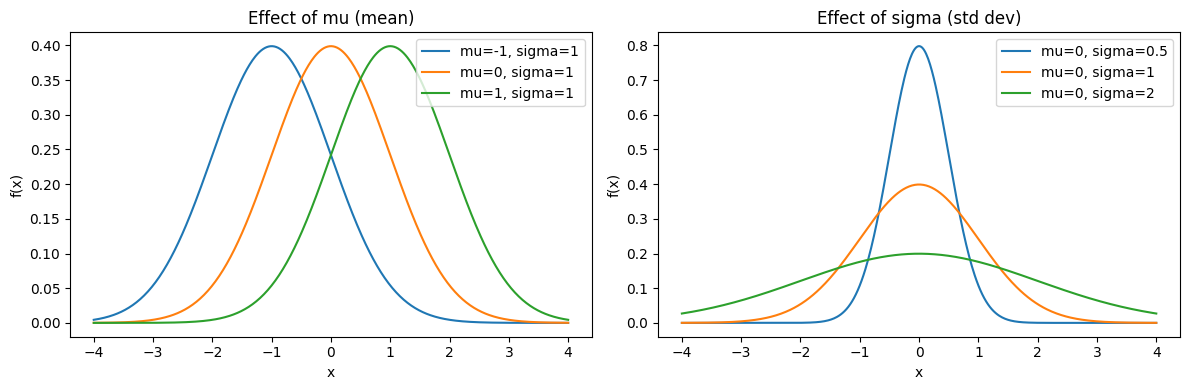

In [12]:
from scipy.stats import norm

x = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: vary mu
for mu in [-1, 0, 1]:
    axes[0].plot(x, norm.pdf(x, mu, 1), label=f'mu={mu}, sigma=1')
axes[0].set_title('Effect of mu (mean)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()

# Right: vary sigma
for sigma in [0.5, 1, 2]:
    axes[1].plot(x, norm.pdf(x, 0, sigma), label=f'mu=0, sigma={sigma}')
axes[1].set_title('Effect of sigma (std dev)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. 우도함수(Likelihood Function)

### 3.1 확률 vs 우도 — 핵심 구분

|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 무엇이 고정? | 무엇이 변수? | 질문 |
|---|---|---|---|
| **확률** $P(X=k \mid \theta)$ | 파라미터 $\theta$ | 데이터 $k$ | 이 $\theta$에서 $k$가 나올 확률은? (앞면이 나올 확률이 0.5인 동전을 3번 던졌을 때 앞면이 2번 나올 확률은?) |
| **우도** $L(\theta \mid X=k)$ | 데이터 $k$ | 파라미터 $\theta$ | 이 $k$를 관측했을 때 $\theta$가 얼마나 그럴듯한가? (3회중 앞면이 2번 나왔을 때,앞면이 나올 확률=0.5는 얼마나 그럴듯한가?)

> 수식은 같지만 **바라보는 방향**이 다릅니다.

$$L(\theta \mid \mathbf{x}) = P(\mathbf{x} \mid \theta) = \prod_{i=1}^n P(x_i \mid \theta)$$

마지막 등호는 데이터 포인트들이 **독립적으로 생성**되었다는 가정(i.i.d.: independent and identically distributed)에서 나옵니다.

ex) $L(p=0.6|[H,T,H])=P([H,T,H]|p=0.6)=P(H|p=0.6)P(T|p=0.6)P(H|p=0.6)$

> 확률은 $p$ 고정, 사건이 변수, 반면, 우도는 사건/데이터 $[H,T,H]$ 고정, $p$가 변수

> 확률은 모든 사건에 대해 더하면(적분하면) 1, 우도는 모든 $p$에 대해 더하면(적분하면) 1 아님

### 3.2 이항분포에서의 우도함수

동전을 $n$번 던져서 $k$번 앞면이 나왔을 때, 이 동전의 앞면이 나올 확률 $p$의 우도:

$$L(p \mid k, n) = \binom{n}{k} p^k (1-p)^{n-k}$$

이 함수를 **$p$의 함수**로 봅니다. $n, k$는 관측된 데이터이므로 고정값입니다.

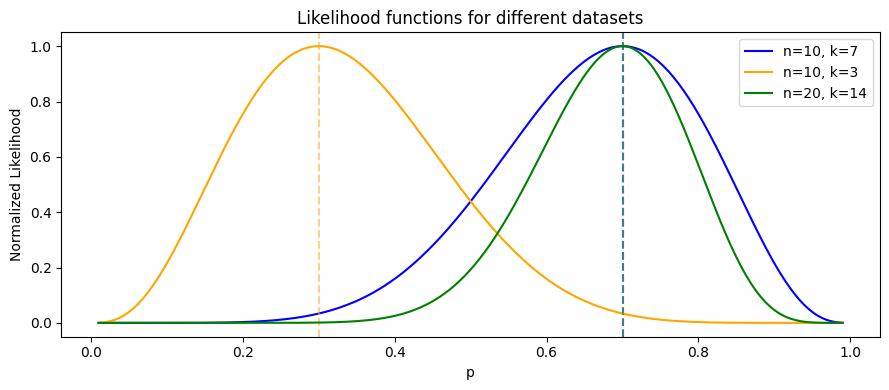

각 데이터셋에서 우도가 최대가 되는 p:
  n=10, k=7 → p_hat = k/n = 0.70
  n=10, k=3 → p_hat = k/n = 0.30
  n=20, k=14 → p_hat = k/n = 0.70


In [15]:
# Likelihood surface for different datasets
p_vals = np.linspace(0.01, 0.99, 300)

datasets = [(10, 7), (10, 3), (20, 14)]
labels   = ['n=10, k=7', 'n=10, k=3', 'n=20, k=14']
colors   = ['blue', 'orange', 'green']

plt.figure(figsize=(9, 4))
for (n, k), label, color in zip(datasets, labels, colors):
    L = [comb(n, k) * p**k * (1-p)**(n-k) for p in p_vals]
    L = np.array(L) / max(L)   # normalize to [0,1] for comparison
    plt.plot(p_vals, L, color=color, label=label)
    plt.axvline(x=k/n, color=color, linestyle='--', alpha=0.5)

plt.xlabel('p')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood functions for different datasets')
plt.legend()
plt.tight_layout()
plt.show()

print("각 데이터셋에서 우도가 최대가 되는 p:")
for n, k in datasets:
    print(f"  n={n}, k={k} → p_hat = k/n = {k/n:.2f}")

---
## 4. 최대우도추정 (MLE, Maximum Likelihood Estimation)

### 4.1 아이디어

> **"관측된 데이터를 가장 그럴듯하게 만드는 파라미터를 찾아라."**

$$\hat{\theta}_{\text{MLE}} = \arg\max_\theta L(\theta \mid \mathbf{x}) = \arg\max_\theta \prod_{i=1}^n P(x_i \mid \theta)$$

### 4.2 log-likelihood를 사용하는 이유

곱(product)은 수치적으로 **언더플로(underflow)** 문제가 있습니다.  
$P(x_i \mid \theta)$가 모두 0.01이라면, $n=100$일 때:

$$\prod_{i=1}^{100} 0.01 = 10^{-200} \approx 0 \quad \text{(컴퓨터가 0으로 반올림!)}$$

로그를 취하면:
$$\ell(\theta) = \log L(\theta) = \sum_{i=1}^n \log P(x_i \mid \theta)$$

- **곱 → 합**: 수치 안정성 확보
- **최적화 불변**: $\log$는 단조증가 함수이므로 최댓값 위치가 바뀌지 않음
- **미분 편리**: $\log$를 씌우면 지수가 아래로 내려와 미분이 쉬워짐

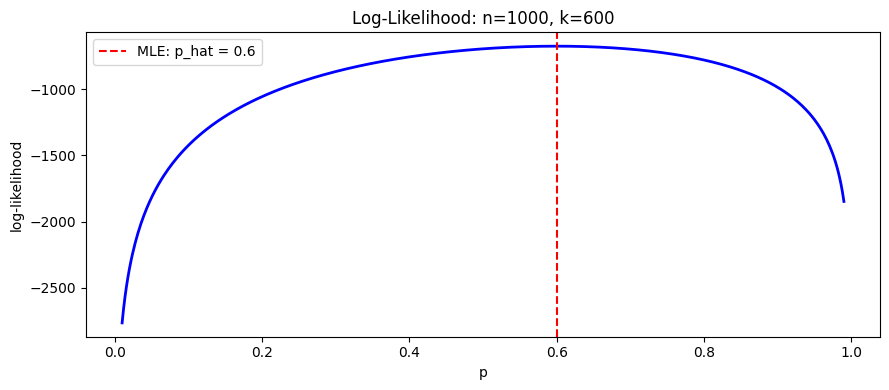

In [13]:
# Numerical stability: likelihood vs log-likelihood
n_large = 1000
p_true  = 0.6
k_large = 600   # 1000번 중 600번 성공

p_vals = np.linspace(0.01, 0.99, 500)

# Raw likelihood (will underflow for large n)
log_L = [k_large * np.log(p) + (n_large - k_large) * np.log(1 - p)
         for p in p_vals]  # log-likelihood (ignoring constant)

plt.figure(figsize=(9, 4))
plt.plot(p_vals, log_L, 'b-', linewidth=2)
plt.axvline(x=k_large/n_large, color='red', linestyle='--',
            label=f'MLE: p_hat = {k_large/n_large}')
plt.xlabel('p')
plt.ylabel('log-likelihood')
plt.title(f'Log-Likelihood: n={n_large}, k={k_large}')
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 이항분포 MLE 수식 유도

**목표:** $n$번 중 $k$번 성공했을 때, $p$의 MLE를 구하자.

**Step 1: log-likelihood 작성**
$$\ell(p) = \log L(p) = \log\binom{n}{k} + k\log p + (n-k)\log(1-p)$$

첫 항 $\log\binom{n}{k}$은 $p$와 무관하므로 최적화에 영향 없음.

**Step 2: $p$에 대해 미분하여 0으로 설정**
$$\frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p} = 0$$

**Step 3: 풀기**
$$\frac{k}{p} = \frac{n-k}{1-p}$$
$$k(1-p) = (n-k)p$$
$$k - kp = np - kp$$
$$k = np$$

$$\boxed{\hat{p}_{\text{MLE}} = \frac{k}{n}}$$

**결론:** MLE 추정값은 관측된 성공 비율입니다 — 우리의 직관과 완벽하게 일치합니다!

In [19]:
# Verify MLE derivation numerically
n, k = 10, 7
p_vals = np.linspace(0.01, 0.99, 99)

# log-likelihood (without constant)
log_L = k * np.log(p_vals) + (n - k) * np.log(1 - p_vals)

p_mle_numerical = p_vals[np.argmax(log_L)]
p_mle_analytical = k / n

print(f"수치 최적화로 찾은 MLE: p_hat = {p_mle_numerical:.4f}")
print(f"수식 유도로 얻은 MLE:   p_hat = k/n = {p_mle_analytical:.4f}")
print(f"두 값이 일치하는가?     {np.isclose(p_mle_numerical, p_mle_analytical, atol=0.01)}")

수치 최적화로 찾은 MLE: p_hat = 0.7000
수식 유도로 얻은 MLE:   p_hat = k/n = 0.7000
두 값이 일치하는가?     True


---
## 5. 익히기 활동 (25분)

### 빈칸 채우기 1 — 조건부 확률 구현

두 주사위를 던질 때, **첫 번째 주사위가 짝수**라는 조건 아래서 **합이 8 이상**일 확률을 구하시오.

In [ ]:
# Fill in the blanks
np.random.seed(0)
N = 200_000

die1 = np.random.randint(1, 7, N)   # first die: 1~6
die2 = np.random.randint(1, 7, N)   # second die: 1~6

# B: first die is even
B = ______  # die1이 짝수인 조건 (True/False 배열)

# A: sum >= 8
A = ______  # die1 + die2 >= 8 인 조건

# P(A|B) = P(A and B) / P(B)
p_B       = B.mean()
p_A_and_B = ______  # A이면서 B인 비율
p_A_given_B = p_A_and_B / p_B

print(f"P(A|B) = {p_A_given_B:.4f}")

### 빈칸 채우기 2 — log-likelihood 함수 구현

이항분포의 log-likelihood를 계산하는 함수를 완성하시오.  
단, $\binom{n}{k}$ 항은 상수이므로 생략합니다.

In [ ]:
def log_likelihood_binomial(p, n, k):
    """
    Compute log-likelihood for Binomial(n, p) given k successes.
    Excludes the log-binomial-coefficient constant.
    """
    return ______   # k * log(p) + (n-k) * log(1-p) 를 채우세요

# Test
n, k = 10, 7
p_range = np.linspace(0.01, 0.99, 300)
ll_vals = [log_likelihood_binomial(p, n, k) for p in p_range]

best_p = p_range[np.argmax(ll_vals)]
print(f"log-likelihood가 최대가 되는 p = {best_p:.3f}")
print(f"이론값 k/n = {k/n:.3f}")

### 빈칸 채우기 3 — MLE 수식 유도 확인

아래 셀에 log-likelihood의 도함수를 직접 수치 미분으로 계산하고,  
$p = k/n$ 근방에서 0에 가장 가까워짐을 확인하시오.

In [ ]:
# Numerical derivative of log-likelihood
n, k = 10, 7
h = 1e-5
p_range = np.linspace(0.05, 0.95, 200)

# d(ell)/dp ≈ (ell(p+h) - ell(p-h)) / (2h)
d_ll = [(log_likelihood_binomial(p+h, n, k) - log_likelihood_binomial(p-h, n, k)) / (2*h)
        for p in p_range]

plt.figure(figsize=(8, 4))
plt.plot(p_range, d_ll, 'b-', label='d(log-likelihood)/dp')
plt.axhline(y=0, color='gray', linestyle='--')
plt.axvline(x=______, color='red', linestyle='--', label='p = k/n (MLE)')  # k/n 을 채우세요
plt.xlabel('p')
plt.ylabel('Derivative')
plt.title('Derivative of Log-Likelihood')
plt.legend()
plt.tight_layout()
plt.show()

### 🐛 버그 문제 — 교실에서 팀활동으로 해결!

아래 코드는 $n=20, k=13$인 데이터에서 이항분포 MLE를 수치적으로 찾으려는 코드입니다.  
실행하면 `p_hat = 0.99` 근방으로 발산합니다. **버그를 찾아 수정하세요.**

In [ ]:
# 🐛 Bug: This code has an error. Find and fix it!
n, k = 20, 13
p_vals = np.linspace(0.01, 0.99, 300)

# Compute likelihood (NOT log-likelihood — intentional for this exercise)
likelihood = p_vals**k + (1 - p_vals)**(n - k)   # <-- 버그가 여기 있습니다

p_hat = p_vals[np.argmax(likelihood)]
print(f"추정된 p_hat = {p_hat:.3f}")
print(f"이론값 k/n  = {k/n:.3f}")

---
## 6. LLM 파트너 가이드

이번 주 개념을 LLM과 함께 깊게 이해하는 프롬프트 예시입니다.  
**답을 바로 요청하지 마세요 — 먼저 내 생각을 설명하고 어디가 틀렸는지 물어보세요.**

---
**프롬프트 1: 우도와 확률 개념 구분**
```
나는 지금 우도(likelihood)와 확률(probability)의 차이를 공부하고 있어.
내 이해: 확률은 파라미터가 고정되었을 때 데이터의 가능성이고,
우도는 데이터가 고정되었을 때 파라미터의 그럴듯함이야.
이 이해가 맞아? 틀린 부분이 있으면 어떤 부분인지 알려줘.
```

---
**프롬프트 2: MLE 유도 점검**
```
이항분포의 MLE 유도 과정을 내가 혼자 해봤어.
[자신이 유도한 과정을 직접 작성]
이 유도가 수학적으로 올바른지 검토해줘.
틀린 단계가 있으면 왜 틀렸는지 설명해주고, 정답은 바로 주지 말고 힌트만 줘.
```

---
**프롬프트 3: 정규분포 MLE로 확장**
```
정규분포 N(mu, sigma^2)에서 데이터 x_1, ..., x_n이 주어졌을 때
mu의 MLE가 표본평균이 됨을 이항분포 MLE 유도 방식과 비교해서 설명해줘.
핵심 단계만 간략하게 알려줘.
```

---

---
## 🔮 Aha Moment 닫기

수업 처음에 본 그래프를 다시 봅시다.

동전 10번 중 앞면 7번 → 우도 곡선의 꼭짓점이 $p = 0.7$인 이유:

$$\frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p} = 0 \implies \hat{p} = \frac{k}{n} = \frac{7}{10} = 0.7$$

**수학적으로 유도된 MLE = 우리의 직관적 추정값**  
이것이 MLE가 강력한 이유입니다.

---
## 다음 주 예고 — 8주차: 로지스틱 회귀 I

분류 문제에서 $P(y=1 \mid x)$를 어떻게 모델링할까요?  
선형 회귀처럼 $\hat{y} = wx + b$로 쓰면 확률이 0~1을 벗어납니다.  
→ **시그모이드 함수**와 **이진 교차엔트로피(BCE)** 가 등장합니다.  
그리고 이 BCE는 이번 주 MLE와 수학적으로 정확히 같은 것입니다!